<a href="https://colab.research.google.com/github/alexdxdd/Barcelona-Tp1-/blob/main/TP1_carto_rmd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# EDA introductorio (no espacial) — Airbnb Barcelona, ​​Cataluña, España
# Distritos (group) y barrios

In [ ]:
# EDA Reconocimiento

In [1]:
# Instalación y carga de paquetes
install.packages("plotly")
install.packages("ggplot2")
install.packages("httr")
install.packages("dplyr")
install.packages("knitr")
install.packages("DT")
install.packages("e1071")
install.packages("leaflet.extras")
install.packages("sf")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘wk’, ‘sp’, ‘terra’, ‘classInt’, ‘s2’, ‘units’, ‘leaflet.providers’, ‘png’, ‘raster’, ‘sf’, ‘leaflet’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
# Carga de paquetes

library(knitr)

library(ggplot2)
library(plotly)
library(httr)
library(dplyr)
library(e1071)
library(sf)



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout



Attaching package: ‘httr’


The following object is masked from ‘package:plotly’:

    config



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.3.1; sf_use_s2() is TRUE



In [3]:
# Carga de datos y representación

datos <-
  read.csv("https://raw.githubusercontent.com/alexdxdd/Barcelona-Tp1-/refs/heads/main/Barcelona%20Tp1.csv")

head(datos)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<chr>,<dbl>,<int>,<int>,<int>,<chr>
1,18674,Huge flat for 8 people close to Sagrada Familia,71615,Mireia,Eixample,la Sagrada Família,41.40556,2.17262,Entire home/apt,210,1,51,2025-07-31,0.34,26,80,7,ESFCTU000008058000039706000000000000000HUTB-002062349
2,23197,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",90417,Etain (Marnie),Sant Martí,el Besòs i el Maresme,41.41243,2.21975,Entire home/apt,285,3,91,2025-09-08,0.52,1,289,12,ESFCTU000008106000547162000000000000000000HUTB0050572
3,32711,Sagrada Familia area - Còrsega 1,135703,Nick,Gràcia,el Camp d'en Grassot i Gràcia Nova,41.40566,2.17015,Entire home/apt,170,1,152,2025-08-08,0.88,2,64,23,HUTB-001722
4,34241,Stylish Top Floor Apartment - Ramblas Plaza Real,73163,Andres,Ciutat Vella,el Barri Gòtic,41.38062,2.17517,Entire home/apt,110,31,25,2024-11-05,0.14,3,333,5,Exempt
5,34981,VIDRE HOME PLAZA REAL on LAS RAMBLAS,73163,Andres,Ciutat Vella,el Barri Gòtic,41.37978,2.17623,Entire home/apt,333,5,271,2025-08-19,1.49,3,335,23,ESFCTU000008119000093652000000000000000HUTB-001506712
6,36763,In front of the beach,158596,Ester,Ciutat Vella,la Barceloneta,41.38043,2.19094,Private room,NA,31,108,2023-12-13,0.64,1,89,0,


In [4]:
# Que tipo de datos tiene cada columna

str(datos)

'data.frame':	19410 obs. of  18 variables:
 $ id                            : num  18674 23197 32711 34241 34981 ...
 $ name                          : chr  "Huge flat for 8 people close to Sagrada Familia" "Forum CCIB DeLuxe, Spacious, Large Balcony, relax" "Sagrada Familia area - Còrsega 1" "Stylish Top Floor Apartment - Ramblas Plaza Real" ...
 $ host_id                       : int  71615 90417 135703 73163 73163 158596 177617 135703 340570 366428 ...
 $ host_name                     : chr  "Mireia" "Etain (Marnie)" "Nick" "Andres" ...
 $ neighbourhood_group           : chr  "Eixample" "Sant Martí" "Gràcia" "Ciutat Vella" ...
 $ neighbourhood                 : chr  "la Sagrada Família" "el Besòs i el Maresme" "el Camp d'en Grassot i Gràcia Nova" "el Barri Gòtic" ...
 $ latitude                      : num  41.4 41.4 41.4 41.4 41.4 ...
 $ longitude                     : num  2.17 2.22 2.17 2.18 2.18 ...
 $ room_type                     : chr  "Entire home/apt" "Entire home/apt" "Entir

In [5]:
# Periodo

min(datos$last_review, na.rm = TRUE)
max(datos$last_review, na.rm = TRUE)

[1] ""

[1] "2025-09-15"

In [6]:
# Cantidad de nulos

sum(duplicated(datos))

sum(is.na(datos))
colSums(is.na(datos))

datos$last_review <- as.Date(datos$last_review)

class(datos$last_review)

[1] 0

[1] 9123

id                           name 
                             0                              0 
                       host_id                      host_name 
                             0                              0 
           neighbourhood_group                  neighbourhood 
                             0                              0 
                      latitude                      longitude 
                             0                              0 
                     room_type                          price 
                             0                           4134 
                minimum_nights              number_of_reviews 
                             0                              0 
                   last_review              reviews_per_month 
                             0                           4989 
calculated_host_listings_count               availability_365 
                             0                              0 
         number_of_reviews_ltm                        license 
                             0                              0

[1] "Date"

In [7]:
# Duplicados

datos <- datos |>
  filter(!is.na(price))

sum(is.na(datos$price))


[1] 0

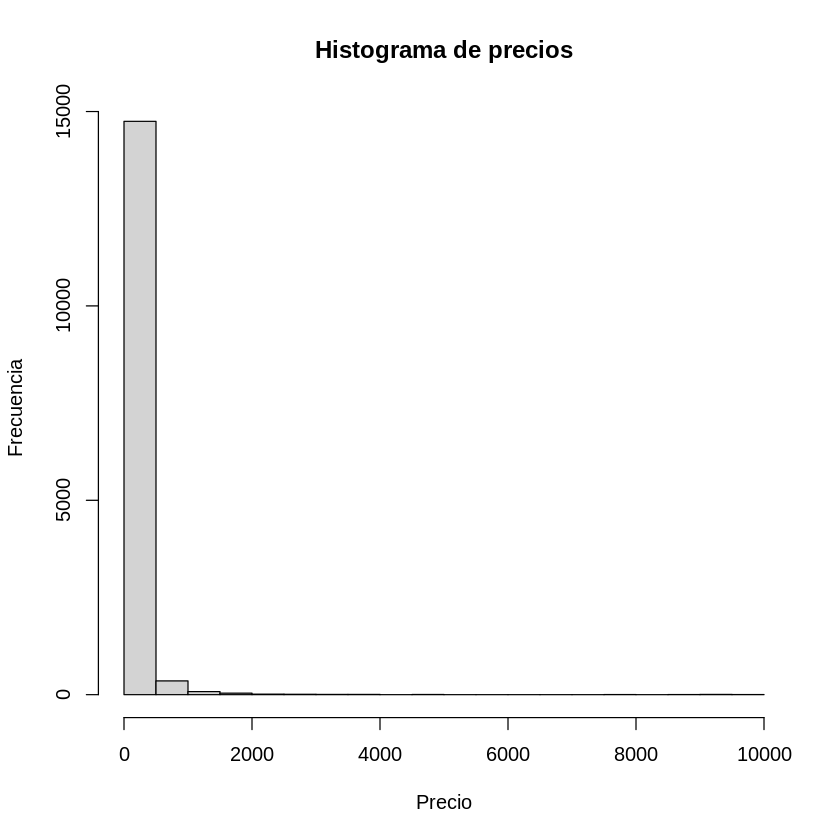

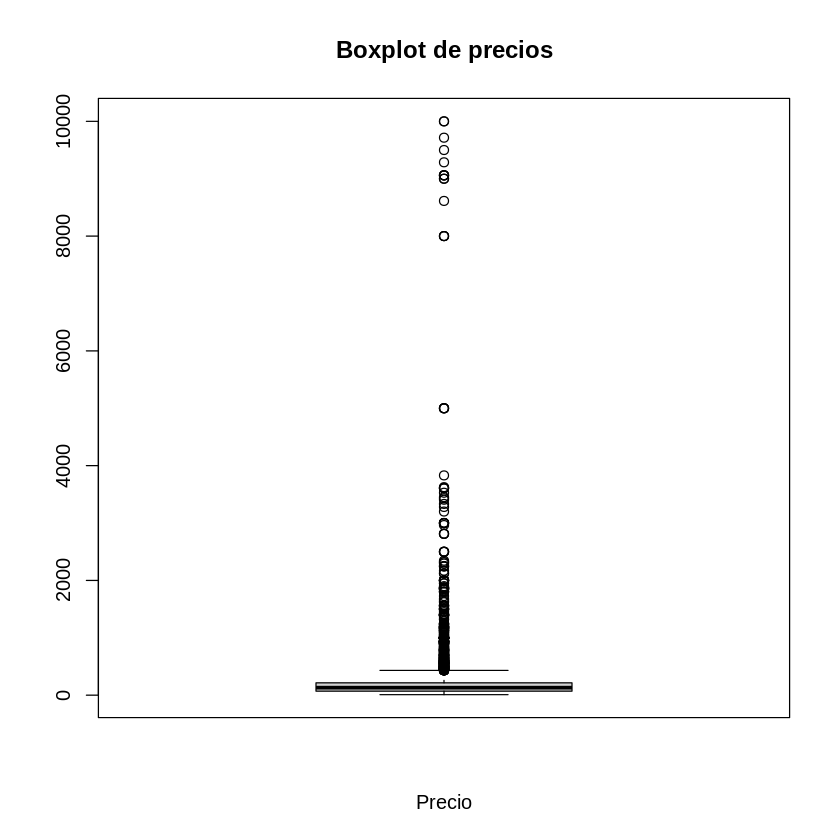

In [8]:
# Histograma y gráfico de cajas

hist(datos$price,
     main = "Histograma de precios",
     xlab = "Precio",
     ylab = "Frecuencia")

boxplot(datos$price,
     main = "Boxplot de precios",
     xlab = "Precio"
     )


In [9]:
# mínimos y másximos en el precio

min(datos$price, na.rm = TRUE)
max(datos$price, na.rm = TRUE)

[1] 9

[1] 10000

In [10]:
# Datos logarítmicos

datos$log_price <-
  log(datos$price)

summary(datos$log_price)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.197   4.248   4.875   4.828   5.371   9.210 

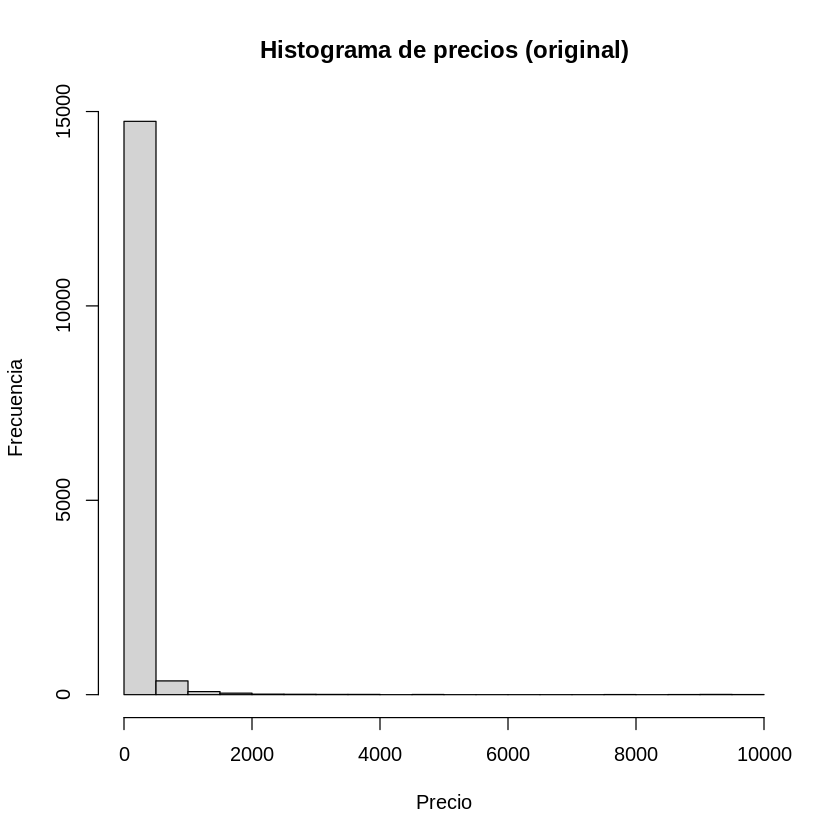

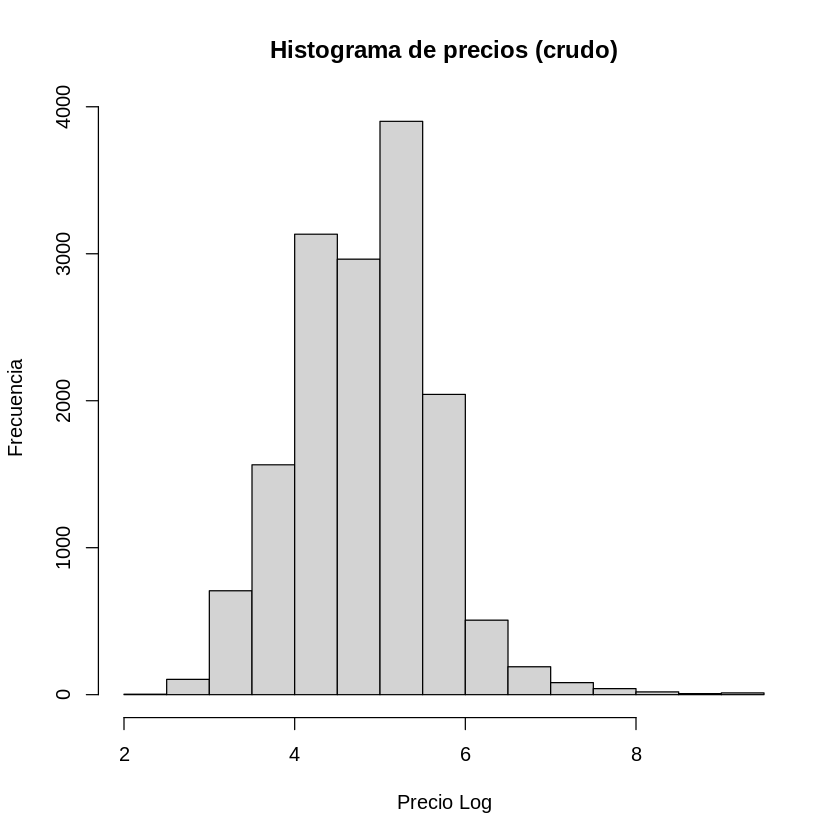

In [11]:
#Comparativa precios original y logaritmicos

hist(datos$price,
     main = "Histograma de precios (original)",
     xlab = "Precio",
     ylab = "Frecuencia")


hist(datos$log_price,
     main = "Histograma de precios (crudo)",
     xlab = "Precio Log",
     ylab = "Frecuencia")



In [12]:
# Percentil 99

p99 <-
  quantile(datos$price, 0.99, na.rm = TRUE)

# Imprimir resultados
cat("Percentil 99 del precio:", round(p99, 2), "\n")
cat("Precio máximo:", max(datos$price, na.rm = TRUE), "\n")

# cat("Relación max / p99:", round(max(datos$price, na.rm = TRUE) / p99, 2), "\n")

Percentil 99 del precio: 1133 
Precio máximo: 10000 


In [13]:
# Evidencia cuantitativa de asimetría

# Media, mediana y asimetría
mean_price <-
  mean(datos$price, na.rm = TRUE)

median_price <-
  median(datos$price, na.rm = TRUE)

skew_price <-
  skewness(datos$price, na.rm = TRUE)

cat("Media:", round(mean_price, 2), "\n")
cat("Mediana:", round(median_price, 2), "\n")
cat("Asimetría (skewness):", round(skew_price, 2), "\n")
cat("Relación media / mediana:", round(mean_price / median_price, 2), "\n")

Media: 187.31 
Mediana: 131 
Asimetría (skewness): 16.44 
Relación media / mediana: 1.43 


In [14]:
# Percentiles 99
p99_price <-
  quantile(datos$price, 0.99, na.rm = TRUE)

p99_min_nights <-
  quantile(datos$minimum_nights, 0.99, na.rm = TRUE)

# Copiar dataframe
df_clean <-
  datos

# Aplicar "capping" (winsorización superior)
df_clean$price_capped <-
  pmin(df_clean$price, p99_price)

df_clean$minimum_nights_capped <-
  pmin(df_clean$minimum_nights, p99_min_nights)

# Resumen descriptivo
summary(df_clean[, c("price", "price_capped", "minimum_nights", "minimum_nights_capped")])

     price          price_capped    minimum_nights   minimum_nights_capped
 Min.   :    9.0   Min.   :   9.0   Min.   :  1.00   Min.   : 1.00        
 1st Qu.:   70.0   1st Qu.:  70.0   1st Qu.:  1.00   1st Qu.: 1.00        
 Median :  131.0   Median : 131.0   Median :  3.00   Median : 3.00        
 Mean   :  187.3   Mean   : 171.9   Mean   : 15.49   Mean   :14.74        
 3rd Qu.:  215.0   3rd Qu.: 215.0   3rd Qu.: 31.00   3rd Qu.:31.00        
 Max.   :10000.0   Max.   :1133.0   Max.   :865.00   Max.   :60.00        

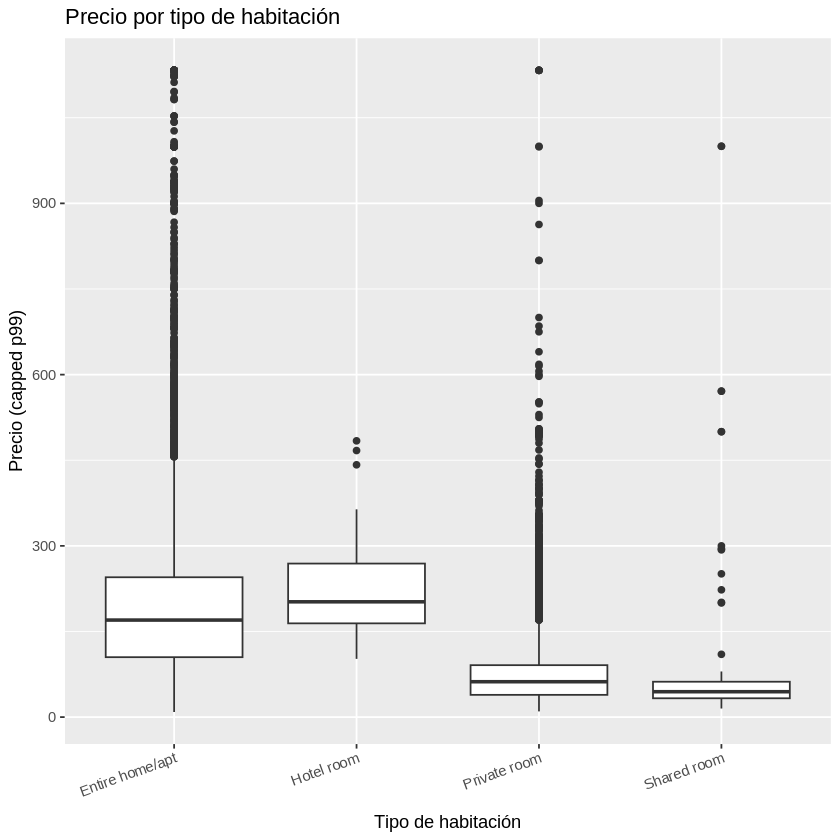

In [15]:
# Precio por tipo de habitación

ggplot(df_clean, aes(x = room_type, y = price_capped)) +
  geom_boxplot() +
  labs(
    title = "Precio por tipo de habitación",
    x = "Tipo de habitación",
    y = "Precio (capped p99)"
  ) +
  theme(axis.text.x = element_text(angle = 20, hjust = 1))

In [38]:
# Convertir a objeto espacial (sf)

# Definir nombres de columnas para latitud y longitud

gdf_airbnb <- st_as_sf(
  datos,
  coords = c("longitude", "latitude"),
  crs = 4326,
  remove = FALSE   # 🔥 CLAVE
)

cat("\nGeoDataFrame Airbnb ✅\n")
cat("CRS:", st_crs(gdf_airbnb)$input, "\n")

# Mostrar primeras filas de las coordenadas
print(head(st_coordinates(gdf_airbnb), 3))


GeoDataFrame Airbnb ✅
CRS: EPSG:4326 
           X        Y
[1,] 2.17262 41.40556
[2,] 2.21975 41.41243
[3,] 2.17015 41.40566


In [40]:
# Mapa de puntos

library(leaflet)

mapa_puntos <-
  leaflet(datos) |>
  addTiles() |>
  addCircleMarkers(
    lng = ~longitude,
    lat = ~latitude,
    popup = ~paste(
      "Precio:", price, "<br>",
      "Tipo:", room_type
    ),
    radius = 4
  )

mapa_puntos

mapa_puntos

HTML widgets cannot be represented in plain text (need html)

In [42]:
# visualización espacial del precio

pal <-
  colorNumeric("viridis", domain = gdf_airbnb$price)

leaflet(gdf_airbnb) |>
  addTiles() |>
  addCircleMarkers(
    color = ~pal(price),
    radius = 4,
    popup = ~paste(
      "Precio:", price, "<br>",
      "Tipo de habitación:", room_type
    )
  ) |>
  addLegend(pal = pal, values = ~price, title = "Precio")


HTML widgets cannot be represented in plain text (need html)

In [36]:
leaflet(gdf_airbnb) |>
  addTiles() |>
  addCircleMarkers(
    popup = ~paste(
      "Precio:", price, "<br>",
      "Tipo:", room_type
    ),
    radius = 4
  )

  gdf_airbnb <- st_as_sf(
  datos,
  coords = c("longitude", "latitude"),
  crs = 4326,
  remove = FALSE   # 🔥 clave
)

HTML widgets cannot be represented in plain text (need html)

In [19]:
library(leaflet)
library(leaflet.extras)

leaflet(gdf_airbnb) |>
  addProviderTiles(providers$CartoDB.Positron) |>
  addHeatmap(
    intensity = ~p99,
    radius = 12,
    blur = 15
  )

HTML widgets cannot be represented in plain text (need html)

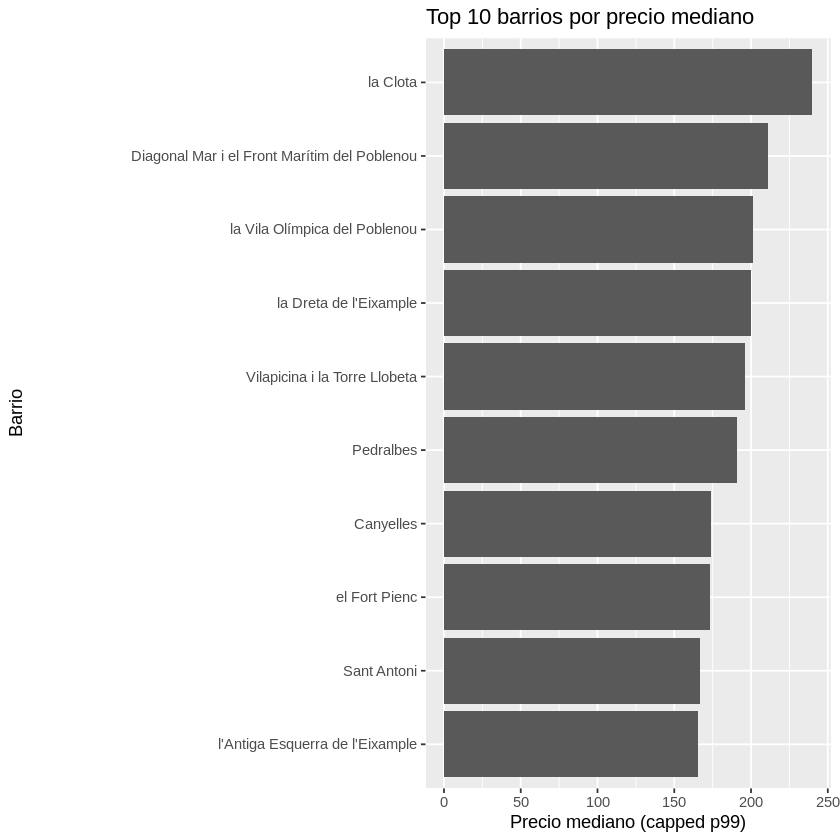

In [20]:
# Gráfico de barras nuevo: top 10 barrios por precio mediano

library(dplyr)

top_barrios <-
  df_clean |>
  group_by(neighbourhood) |>
  summarise(
    mediana_precio = median(price_capped, na.rm = TRUE),
    n = n()
  ) |>
  arrange(desc(mediana_precio)) |>
  slice_head(n = 10)

# Gráfico
ggplot(top_barrios, aes(x = reorder(neighbourhood, mediana_precio),
                        y = mediana_precio)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 barrios por precio mediano",
    x = "Barrio",
    y = "Precio mediano (capped p99)"
  )

In [ ]:
# Explicación
# Con el gráfico hecho, se puede ver que hay una coincidencia parcial, los primeros 3 si coinciden ya que son barrios céntricos,
# cercanos a la costa y en zonas turísticas, en contraste con esto tenemos al quinto barrio "Vilapicina i la Torre Llobeta" el cual no es uuna zona
# típicamente "cara". Esto nos sugiere que los datos de Airbnb no reflejan exactamente la estructura social o económica.